In [ ]:
import sys
sys.path.append("..")
import random
from typing import Dict, List
import numpy as np
import pandas as pd
import torch
import torchmetrics
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
from src.modules.lcm_module import LCMModule
from src.utils.misc_utils import load_sharded_dataset, load_full_dataset
from src.utils.metrics import custom_binary_metrics
from src.utils.utils import lagged_batch_crosscorrelation

import warnings
warnings.filterwarnings("ignore")

roc = torchmetrics.classification.BinaryROC()
auroc = torchmetrics.classification.BinaryAUROC()

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [ ]:
BASE_DIR = Path("/home/nikolas/LCM-paper/logs")
MODEL_SIZES = ["500K", "1M", "2M"]
DATA_SIZES = ["10K", "25K", "50K", "100K"]
SEEDS = [42, 43, 44, 45, 46]
DATA_SIZE_NUMERIC = {"10K": 1e4, "25K": 2.5e4, "50K": 5e4, "100K": 1e5}

CPD_PATH = Path("/media/nikolas/KINGSTON/Datasets/sized_data/size_10000/")
SPLIT = 'val'
SHARDED_DATA = True

MAX_VAR = 12
MAX_LAG = 3

device = "cpu"

def evaluation_loop(model_name: str, model, cpd_path: Path, split: str = 'val', sharded_data: bool = True) -> List[float]:
    """
    Returns a list of AUROC values (one per shard*sample).
    This is your evaluation code, wrapped into a reusable function.
    """
    if sharded_data:
        dataset_iterator = load_sharded_dataset(cpd_path, split)
    else:
        dataset_iterator = [load_full_dataset(cpd_path, split)]

    auc_list = []
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    for shard_idx, data in enumerate(dataset_iterator):
        for idx in tqdm(range(len(data)), desc=f"[{model_name}] Shard {shard_idx}"):
            X_cpd = data[idx][0]
            Y_cpd = data[idx][-1]

            if isinstance(Y_cpd, np.ndarray):
                Y_cpd = torch.from_numpy(Y_cpd)

            M = model.model
            M = M.to(device)
            M = M.eval()

            # normalization
            X_cpd = (X_cpd - X_cpd.min()) / (X_cpd.max() - X_cpd.min())

            assert X_cpd.shape[1] <= MAX_VAR
            assert Y_cpd.shape[1] <= MAX_VAR
            assert Y_cpd.shape[2] <= MAX_LAG

            # padding
            VAR_DIF = MAX_VAR - X_cpd.shape[1]
            LAG_DIF = MAX_LAG - Y_cpd.shape[2]

            if VAR_DIF > 0:
                X_cpd = torch.concat([X_cpd, torch.normal(0, 0.01, (X_cpd.shape[0], VAR_DIF))], axis=1)
                Y_cpd = torch.nn.functional.pad(Y_cpd, (0, 0, 0, VAR_DIF, 0, VAR_DIF), mode="constant", value=0.0)

            if LAG_DIF > 0:
                Y_cpd = torch.nn.functional.pad(Y_cpd, (LAG_DIF, 0, 0, 0, 0, 0), mode="constant", value=0.0)

            # forward pass
            if X_cpd.shape[0] > 500:
                X_sub = X_cpd[:500]
                pred = torch.sigmoid(M((X_sub.unsqueeze(0), lagged_batch_crosscorrelation(X_sub.unsqueeze(0), MAX_LAG)))[0])
                pred = pred.unsqueeze(0)
            else:
                with torch.no_grad():
                    pred = torch.sigmoid(M((X_cpd.unsqueeze(0), lagged_batch_crosscorrelation(X_cpd.unsqueeze(0), MAX_LAG))))

            Y_cpd[Y_cpd < 0.05] = 0
            Y_cpd[Y_cpd >= 0.05] = 1

            _, _, _, _, auc = custom_binary_metrics(binary=pred[0], A=Y_cpd, verbose=False)
            auc_list.append(float(auc))

    return auc_list

results: Dict[str, Dict[str, List[float]]] = {
    ms: {ds: [] for ds in DATA_SIZES} for ms in MODEL_SIZES
}

for ms in MODEL_SIZES:
    for ds in DATA_SIZES:
        for seed in SEEDS:
            ckpt_path = BASE_DIR / ms / ds / f"seed{seed}.ckpt"

            if not ckpt_path.exists():
                print(f"[skip] Missing checkpoint: {ckpt_path}")
                continue

            print(f"\n--- Loading {ms} / {ds} / seed={seed} ---")
            model = LCMModule.load_from_checkpoint(ckpt_path)

            auc_vals = evaluation_loop(f"{ms}-{ds}-seed{seed}", model, CPD_PATH, split=SPLIT, sharded_data=SHARDED_DATA)

            results[ms][ds].append(np.mean(auc_vals))

            del model
            torch.cuda.empty_cache() if torch.cuda.is_available() else None


plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.dpi": 300,
})

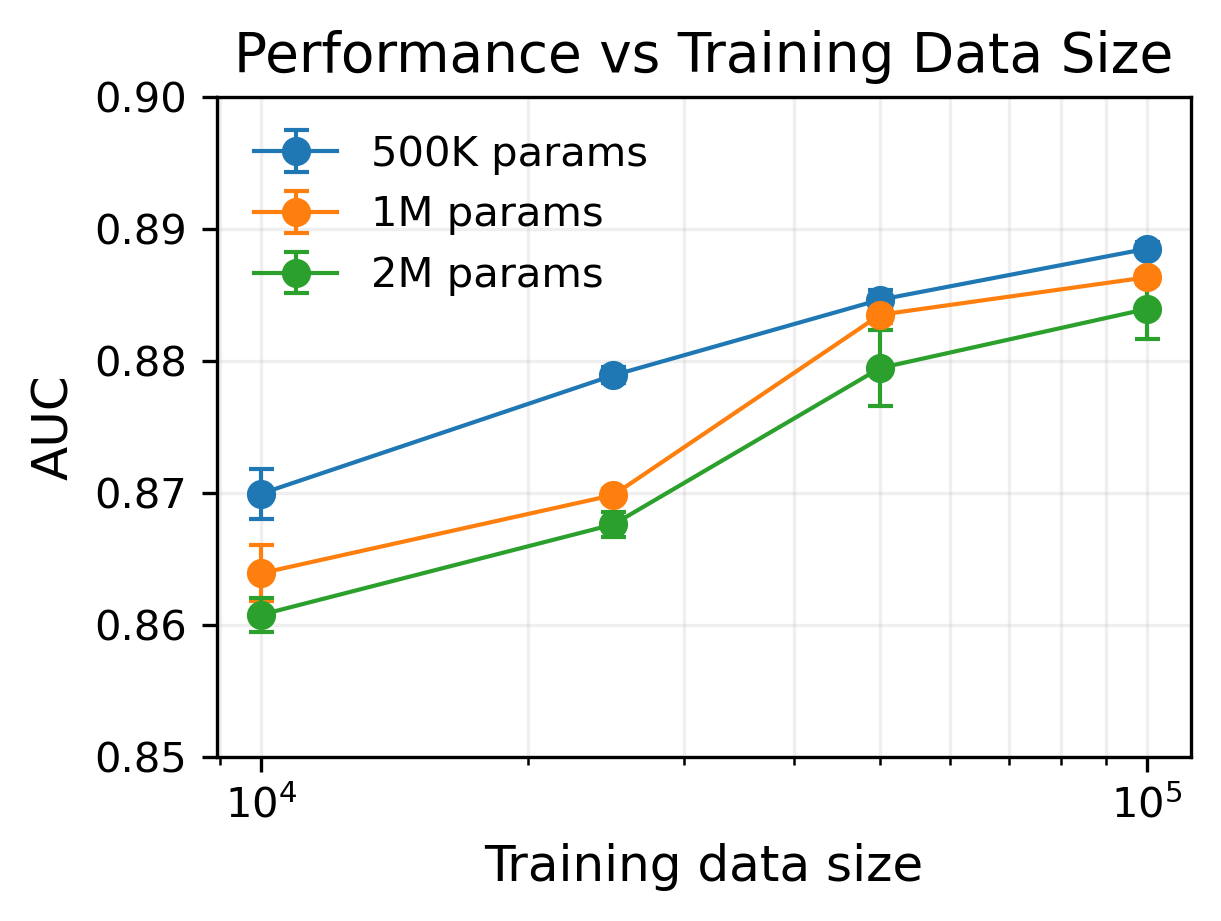

In [16]:
fig, ax = plt.subplots(figsize=(4.2, 3.2))

MODEL_SIZES = ["500K", "1M", "2M"]
DATA_SIZES = ["10K", "25K", "50K", "100K"]
SEEDS = [42, 43, 44, 45, 46]
DATA_SIZE_NUMERIC = {"10K": 1e4, "25K": 2.5e4, "50K": 5e4, "100K": 1e5}

for ms in MODEL_SIZES:
    xs, means, stds = [], [], []
    for ds in DATA_SIZES:
        vals = results[ms][ds]
        if len(vals) == 0:
            continue
        xs.append(DATA_SIZE_NUMERIC[ds])
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    ax.errorbar(
        xs, means, yerr=stds,
        label=f"{ms} params",
        marker="o", linestyle="-", linewidth=1, capsize=3
    )

ax.set_xscale("log")
ax.set_xlabel("Training data size")
ax.set_ylabel("AUC")
ax.set_title("Performance vs Training Data Size")
ax.set_ylim(0.85, 0.9)
ax.grid(alpha=0.2, which="both")
ax.legend(frameon=False)

plt.tight_layout()